In [ ]:
from google.colab import files
files.upload()  # Sube tu kaggle.json aquí

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"pablojusticia","key":"KGAT_f9ee2aa73036019c203b9d5ebbc12332"}'}

In [ ]:
import os
os.makedirs("/root/.config/kaggle", exist_ok=True)
os.rename("/content/kaggle.json", "/root/.config/kaggle/kaggle.json")
os.chmod("/root/.config/kaggle/kaggle.json", 0o600)
print("✅ Kaggle configurado")

✅ Kaggle configurado


In [ ]:
!kaggle datasets download -d fatemehmehrparvar/obesity-levels --unzip
print("✅ Dataset descargado")

Dataset URL: https://www.kaggle.com/datasets/fatemehmehrparvar/obesity-levels
License(s): Attribution 4.0 International (CC BY 4.0)
100% 57.6k/57.6k [00:00<00:00, 39.9MB/s]

✅ Dataset descargado


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("✅ Librerías cargadas")

✅ Librerías cargadas


In [ ]:
df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")

print("=== Primeras 5 filas ===")
print(df.head())
print(f"\nFilas: {df.shape[0]}, Columnas: {df.shape[1]}")
print("\n=== Valores nulos ===")
print(df.isnull().sum())
print("\n=== Clases de obesidad ===")
print(df['NObeyesdad'].value_counts())

=== Primeras 5 filas ===
    Age  Gender  Height  Weight        CALC FAVC  FCVC  NCP  SCC SMOKE  CH2O  \
0  21.0  Female    1.62    64.0          no   no   2.0  3.0   no    no   2.0   
1  21.0  Female    1.52    56.0   Sometimes   no   3.0  3.0  yes   yes   3.0   
2  23.0    Male    1.80    77.0  Frequently   no   2.0  3.0   no    no   2.0   
3  27.0    Male    1.80    87.0  Frequently   no   3.0  3.0   no    no   2.0   
4  22.0    Male    1.78    89.8   Sometimes   no   2.0  1.0   no    no   2.0   

  family_history_with_overweight  FAF  TUE       CAEC                 MTRANS  \
0                            yes  0.0  1.0  Sometimes  Public_Transportation   
1                            yes  3.0  0.0  Sometimes  Public_Transportation   
2                            yes  2.0  1.0  Sometimes  Public_Transportation   
3                             no  2.0  0.0  Sometimes                Walking   
4                             no  0.0  0.0  Sometimes  Public_Transportation   

            N

In [ ]:
df_clean = df.copy()

le = LabelEncoder()
categorical_cols = ['Gender', 'CALC', 'FAVC', 'SCC', 'SMOKE',
                    'family_history_with_overweight', 'CAEC', 'MTRANS']

for col in categorical_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

df_clean['NObeyesdad'] = le.fit_transform(df_clean['NObeyesdad'])

print("=== Clases codificadas ===")
for i, clase in enumerate(le.classes_):
    print(f"  {i} = {clase}")

=== Clases codificadas ===
  0 = Insufficient_Weight
  1 = Normal_Weight
  2 = Obesity_Type_I
  3 = Obesity_Type_II
  4 = Obesity_Type_III
  5 = Overweight_Level_I
  6 = Overweight_Level_II


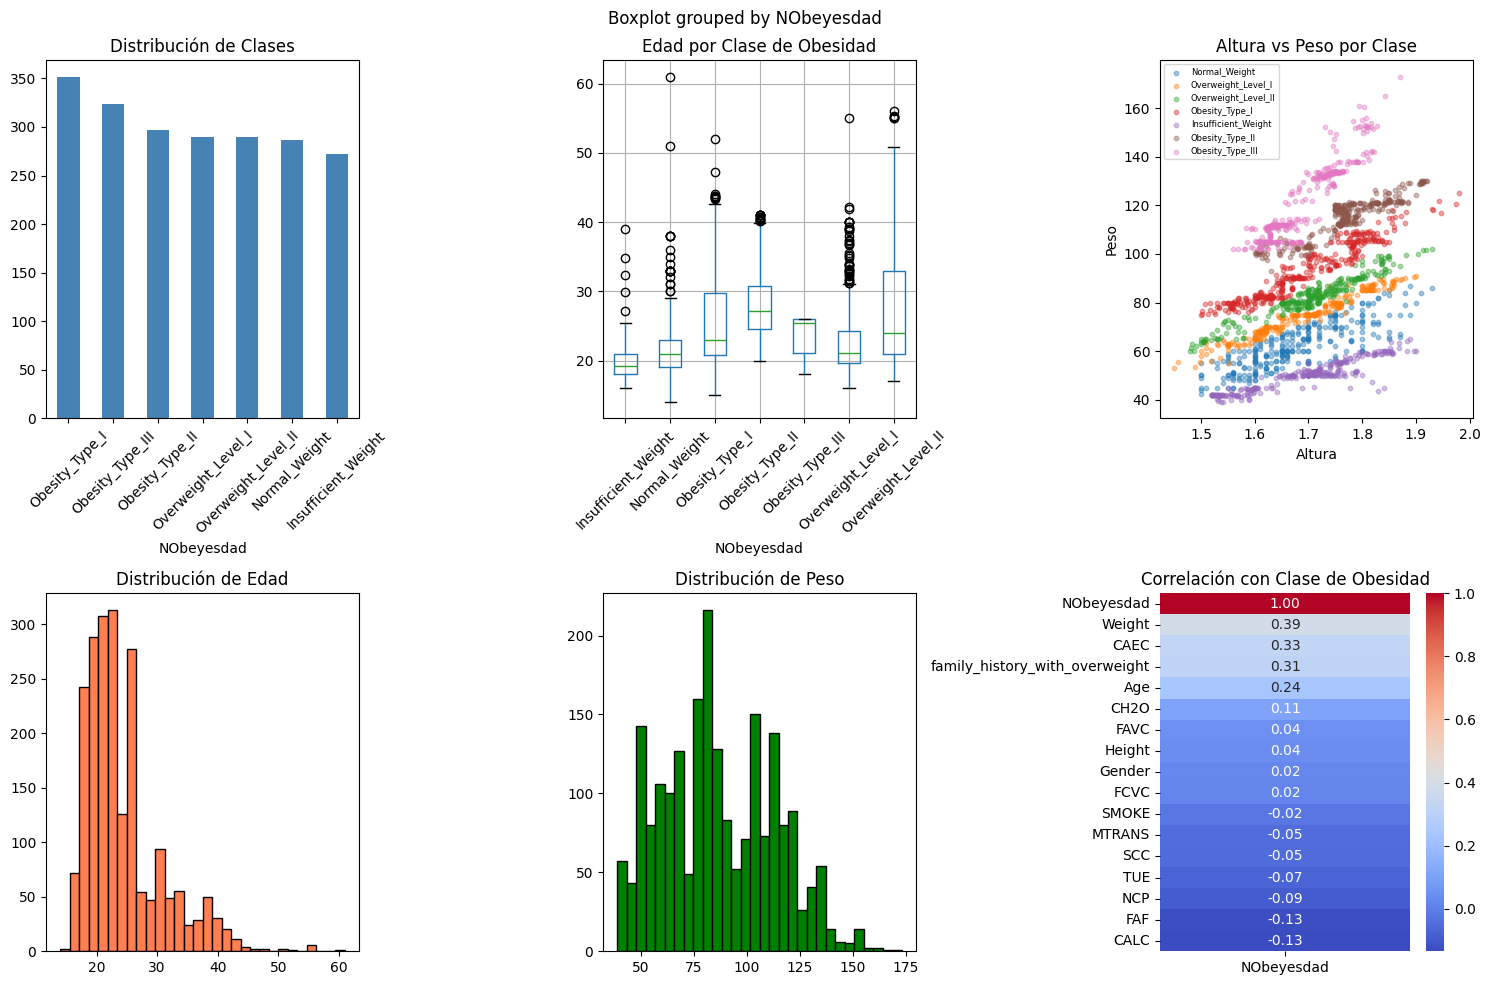

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Análisis del Dataset - Obesity Levels', fontsize=16)

df['NObeyesdad'].value_counts().plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Distribución de Clases')
axes[0,0].tick_params(axis='x', rotation=45)

df.boxplot(column='Age', by='NObeyesdad', ax=axes[0,1])
axes[0,1].set_title('Edad por Clase de Obesidad')
axes[0,1].tick_params(axis='x', rotation=45)

for clase in df['NObeyesdad'].unique():
    mask = df['NObeyesdad'] == clase
    axes[0,2].scatter(df[mask]['Height'], df[mask]['Weight'],
                      alpha=0.4, label=clase, s=10)
axes[0,2].set_title('Altura vs Peso por Clase')
axes[0,2].set_xlabel('Altura')
axes[0,2].set_ylabel('Peso')
axes[0,2].legend(fontsize=6)

axes[1,0].hist(df['Age'], bins=30, color='coral', edgecolor='black')
axes[1,0].set_title('Distribución de Edad')

axes[1,1].hist(df['Weight'], bins=30, color='green', edgecolor='black')
axes[1,1].set_title('Distribución de Peso')

corr = df_clean.corr()
sns.heatmap(corr[['NObeyesdad']].sort_values('NObeyesdad', ascending=False),
            annot=True, ax=axes[1,2], cmap='coolwarm', fmt='.2f')
axes[1,2].set_title('Correlación con Clase de Obesidad')

plt.tight_layout()
plt.show()

In [ ]:
X = df_clean.drop(columns=['NObeyesdad'])
y = df_clean['NObeyesdad']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Datos de entrenamiento: {X_train.shape}")
print(f"Datos de test: {X_test.shape}")
print("✅ Datos listos para entrenar")

Datos de entrenamiento: (1688, 16)
Datos de test: (423, 16)
✅ Datos listos para entrenar


In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

rf_pred = rf_model.predict(X_test_scaled)
rf_accuracy = accuracy_score(y_test, rf_pred)

print("=== Random Forest - Resultados ===")
print(f"Accuracy: {rf_accuracy:.4f}")
print("\nReporte detallado:")
print(classification_report(y_test, rf_pred,
      target_names=['Insufficient','Normal','Obesity_I',
                    'Obesity_II','Obesity_III','Overweight_I','Overweight_II']))

=== Random Forest - Resultados ===
Accuracy: 0.9574

Reporte detallado:
               precision    recall  f1-score   support

 Insufficient       1.00      0.93      0.96        54
       Normal       0.84      0.98      0.90        58
    Obesity_I       0.96      0.97      0.96        70
   Obesity_II       1.00      0.98      0.99        60
  Obesity_III       1.00      0.98      0.99        65
 Overweight_I       0.96      0.90      0.93        58
Overweight_II       0.96      0.95      0.96        58

     accuracy                           0.96       423
    macro avg       0.96      0.96      0.96       423
 weighted avg       0.96      0.96      0.96       423



In [ ]:
model = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(7, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

print("✅ Red neuronal entrenada")

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4252 - loss: 1.6344 - val_accuracy: 0.5858 - val_loss: 1.1738
Epoch 2/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6341 - loss: 0.9798 - val_accuracy: 0.7456 - val_loss: 0.7554
Epoch 3/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7459 - loss: 0.6924 - val_accuracy: 0.7899 - val_loss: 0.6091
Epoch 4/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7689 - loss: 0.5850 - val_accuracy: 0.8195 - val_loss: 0.5015
Epoch 5/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8259 - loss: 0.4838 - val_accuracy: 0.8402 - val_loss: 0.4400
Epoch 6/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8444 - loss: 0.4261 - val_accuracy: 0.8580 - val_loss: 0.3857
Epoch 7/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8526 - loss: 0.3947 - val_accuracy: 0.8698 - val_loss: 0.3573
Epoch 8/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8652 - loss: 0.3375 - val_accuracy: 0.8728 - val_loss: 0.3

In [ ]:
nn_loss, nn_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
nn_pred = np.argmax(model.predict(X_test_scaled), axis=1)

print("=== Red Neuronal - Resultados ===")
print(f"Accuracy: {nn_accuracy:.4f}")
print("\nReporte detallado:")
print(classification_report(y_test, nn_pred,
      target_names=['Insufficient','Normal','Obesity_I',
                    'Obesity_II','Obesity_III','Overweight_I','Overweight_II']))

print("\n=== Comparación Final ===")
print(f"{'Modelo':<20} {'Accuracy':>10}")
print(f"{'Random Forest':<20} {rf_accuracy:>10.4f}")
print(f"{'Red Neuronal':<20} {nn_accuracy:>10.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
=== Red Neuronal - Resultados ===
Accuracy: 0.9504

Reporte detallado:
               precision    recall  f1-score   support

 Insufficient       0.93      1.00      0.96        54
       Normal       0.93      0.88      0.90        58
    Obesity_I       0.92      1.00      0.96        70
   Obesity_II       0.98      0.98      0.98        60
  Obesity_III       1.00      0.98      0.99        65
 Overweight_I       0.93      0.88      0.90        58
Overweight_II       0.96      0.91      0.94        58

     accuracy                           0.95       423
    macro avg       0.95      0.95      0.95       423
 weighted avg       0.95      0.95      0.95       423


=== Comparación Final ===
Modelo                 Accuracy
Random Forest            0.9574
Red Neuronal             0.9504


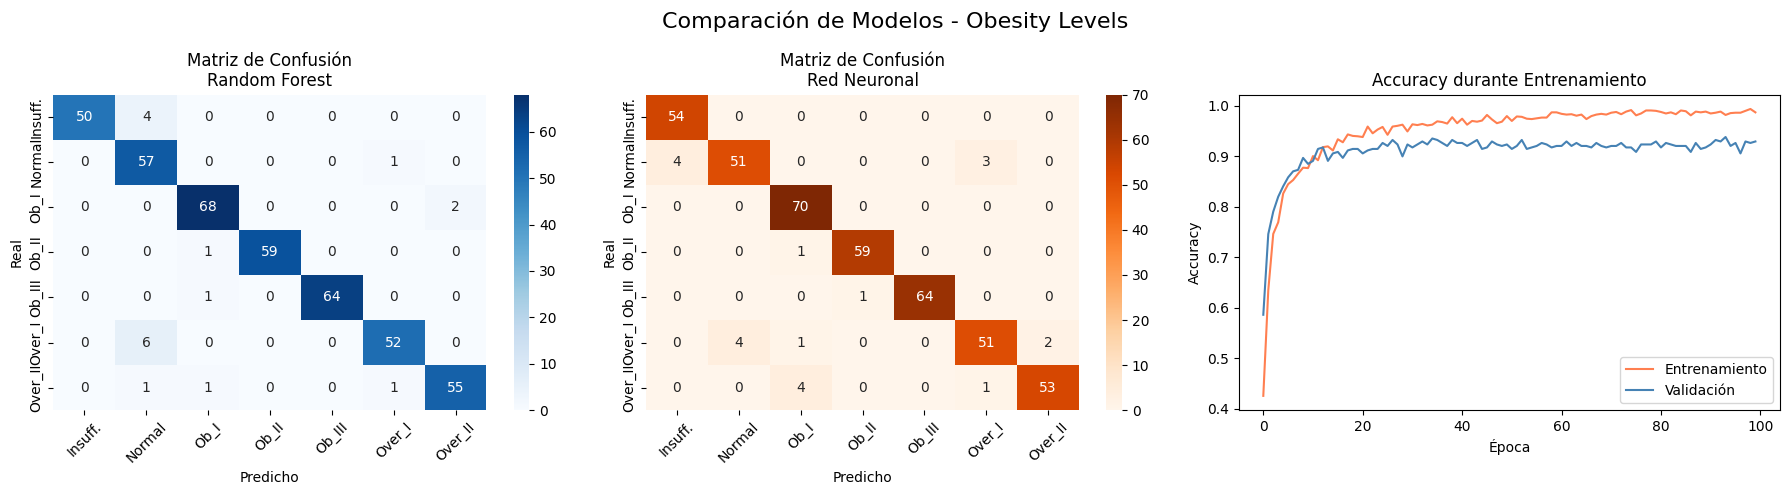

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Comparación de Modelos - Obesity Levels', fontsize=16)

clases = ['Insuff.','Normal','Ob_I','Ob_II','Ob_III','Over_I','Over_II']

cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', ax=axes[0],
            cmap='Blues', xticklabels=clases, yticklabels=clases)
axes[0].set_title('Matriz de Confusión\nRandom Forest')
axes[0].set_xlabel('Predicho')
axes[0].set_ylabel('Real')
axes[0].tick_params(axis='x', rotation=45)

cm_nn = confusion_matrix(y_test, nn_pred)
sns.heatmap(cm_nn, annot=True, fmt='d', ax=axes[1],
            cmap='Oranges', xticklabels=clases, yticklabels=clases)
axes[1].set_title('Matriz de Confusión\nRed Neuronal')
axes[1].set_xlabel('Predicho')
axes[1].set_ylabel('Real')
axes[1].tick_params(axis='x', rotation=45)

axes[2].plot(history.history['accuracy'], label='Entrenamiento', color='coral')
axes[2].plot(history.history['val_accuracy'], label='Validación', color='steelblue')
axes[2].set_title('Accuracy durante Entrenamiento')
axes[2].set_xlabel('Época')
axes[2].set_ylabel('Accuracy')
axes[2].legend()

plt.tight_layout()
plt.show()